<a href="https://colab.research.google.com/github/c4u534/AutoPoET/blob/main/Evolving_Spatial_Awareness_Beyond_Isomorphic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extending mathematical morphology to the Special Euclidean group $SE(2) \cong \mathbb{R}^2 \rtimes SO(2)$ transitions spatial cognition from isotropic point-agent approximations to full rigid-body state-space dynamics. When non-holonomic kinematic limits (such as bounded curvature in Dubins or Reeds-Shepp systems) are introduced, Euclidean metric structuring elements are replaced by sub-Riemannian reachable control sets.

---

### 1. Lifting Morphological Operations to the $SE(2)$ Fiber Bundle

A configuration in the plane with orientation is parameterized by $q = (\mathbf{x}, \theta) = (x, y, \theta) \in SE(2)$, where $\mathbf{x} \in \mathbb{R}^2$ and $\theta \in S^1 \cong [0, 2\pi)$.

#### Group Action and Asymmetric Footprints

Let the agent's reference body footprint at the origin with zero orientation be $\mathcal{B}_0 \subset \mathbb{R}^2$. The rotated and translated body at configuration $q$ is governed by the $SE(2)$ group action on $\mathbb{R}^2$:

$$\mathcal{B}(q) = \mathbf{R}(\theta)\mathcal{B}_0 + \mathbf{x}$$

where $\mathbf{R}(\theta) \in SO(2)$ is the standard planar rotation matrix:

$$\mathbf{R}(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

#### Foliated Configuration Space Obstacles

The configuration space obstacle region $\mathcal{C}_{obs} \subset SE(2)$ is the set of all poses where the transformed body intersects the workspace obstacle set $\mathcal{O} \subset \mathbb{R}^2$:

$$\mathcal{C}_{obs} = \{ (\mathbf{x}, \theta) \in SE(2) \mid \mathcal{B}(\mathbf{x}, \theta) \cap \mathcal{O} \neq \emptyset \}$$

Because translation and rotation decouple along the $S^1$ fiber, $\mathcal{C}_{obs}$ can be expressed as a continuous foliation of standard 2D Minkowski sums parameterized by the fiber angle $\theta$:

$$\mathcal{C}_{obs}(\theta) = \mathcal{O} \oplus \check{\mathcal{B}}(\theta) = \{ \mathbf{p} + \mathbf{b} \mid \mathbf{p} \in \mathcal{O}, \, \mathbf{b} \in -\mathbf{R}(\theta)\mathcal{B}_0 \}$$

$$\mathcal{C}_{obs} = \bigcup_{\theta \in [0, 2\pi)} \Big( \mathcal{C}_{obs}(\theta) \times \{\theta\} \Big)$$

```
     θ (Orientation Fiber)
      ▲
 2π   │     ┌───────────┐      Slice θ_2: O ⊕ B̌(θ_2)
      │    ╱           ╱│
      │   ┌───────────┐ │
 θ_i  │   │  C_obs    │ │      Slice θ_1: O ⊕ B̌(θ_1)
      │   │ (Inflated)│ ┘
  0   └───┴───────────┴────► (x, y) Base Manifold

```

---

### 2. Group Morphology on $SE(2)$

In classical morphology, dilation commutes with translations. On $SE(2)$, Euclidean translation covariance generalizes to **left-invariance under rigid body motions**.

For group elements $g, h \in SE(2)$, let the group multiplication be defined by the semidirect product:

$$g \cdot h = (\mathbf{x}_g, \theta_g) \cdot (\mathbf{x}_h, \theta_h) = \left(\mathbf{x}_g + \mathbf{R}(\theta_g)\mathbf{x}_h, \, (\theta_g + \theta_h) \pmod{2\pi}\right)$$

The left-invariant group dilation ($\oplus_G$) and erosion ($\ominus_G$) of a spatial cognitive belief field $X \subset SE(2)$ by a structuring element $K \subset SE(2)$ are:

$$(X \oplus_G K) = \bigcup_{g \in X} g \cdot K = \{ g \cdot k \mid g \in X, \, k \in K \}$$

$$(X \ominus_G K) = \{ g \in SE(2) \mid g \cdot K \subseteq X \}$$

This formulation guarantees that spatial reasoning remains invariant regardless of the global reference frame chosen by the observer.

---

### 3. Non-Holonomic Constraints as Anisotropic Structuring Kernels

A non-holonomic vehicle (e.g., car-like robot or differential drive) cannot translate sideways. Its instantaneous motion is constrained by the Pfaffian constraint:

$$-\dot{x}\sin\theta + \dot{y}\cos\theta = 0 \implies \begin{bmatrix} \dot{x} \\ \dot{y} \\ \dot{\theta} \end{bmatrix} = \begin{bmatrix} \cos\theta \\ \sin\theta \\ 0 \end{bmatrix} v + \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix} \omega$$

Subject to a bounded turning radius $R_{min} = 1/\kappa_{max}$:

$$\left\vert{} \frac{\omega}{v} \right\vert{} \le \kappa_{max}$$

#### From Euclidean Balls to Reachability Kernels

In holonomic systems, dynamic safety horizons are generated by isotropic structuring elements ($r\mathcal{B}$). Under non-holonomic constraints, the morphological structuring element must be replaced by the **Sub-Riemannian / Dubins Reachability Kernel** $\mathcal{K}_{\Delta s}$:

$$\mathcal{K}_{\Delta s} = \left\{ q \in SE(2) \;\middle\vert{}\; \exists \, u(t) \in [-\kappa_{max}, \kappa_{max}], \; \int_0^{\tau} \Vert{}\dot{\mathbf{x}}(t)\Vert{} dt \le \Delta s, \; \tau > 0 \right\}$$

Dilating a single configuration $q_0$ by $\mathcal{K}_{\Delta s}$ yields the forward reachable "trumpet" or reachable bulb in $SE(2)$ space, rather than a 3D cylinder.

```
       Holonomic Workspace Dilation            Non-Holonomic Kinematic Kernel
             (Isotropic Disk)                     (Dubins Reachability Cone)

                 ┌─────┐                                     .-'""'-.
              ┌──┘     └──┐                                .'  Left  '.
              │     •     │                               /      ▲     \
              └──┐     ┌──┘                              │       │      │
                 └─────┘                                  \    Forward /
                                                           '.   │   .'
                                                             '-.|.-'
                                                               (q)

```

#### Curvature-Constrained Medial Axis Pruning

The Euclidean medial axis $\mathcal{S}(\mathcal{C}_{free})$ is generally dynamically unexecutable because its branches can form sharp corners ($C^0$ discontinuities) or exhibit curvature $\kappa(s) > \kappa_{max}$.

To extend skeletonization to $SE(2)$:

1. Lift the free configuration space to $SE(2)$: $\mathcal{C}_{free} = SE(2) \setminus \mathcal{C}_{obs}$.
2. Compute the distance transform under the **Carnot-Carathéodory / Dubins metric** $d_{kin}(q_1, q_2)$.
3. Prune points where the local clearance circle requires an instantaneous turning curvature exceeding the vehicle's turning capability:

$$\mathcal{S}_{kin}(\mathcal{C}_{free}) = \left\{ q \in \mathcal{S}(\mathcal{C}_{free}) \;\middle\vert{}\; \kappa(\mathcal{S}_{proj}(q)) \le \kappa_{max} \right\}$$

---

### 4. Python Implementation: $SE(2)$ Morphological C-Space and Kinematic Lattice Search

The following script:

1. Constructs an asymmetric rectangular footprint.
2. Discretizes orientation into slices $\theta_k \in [0, 2\pi)$.
3. Computes the 3D $\mathcal{C}_{obs}$ via slice-wise rotated 2D morphological dilations.
4. Plans a non-holonomic, bounded-curvature trajectory through the 3D configuration volume using forward kinematic primitives (straight, left turn, right turn).

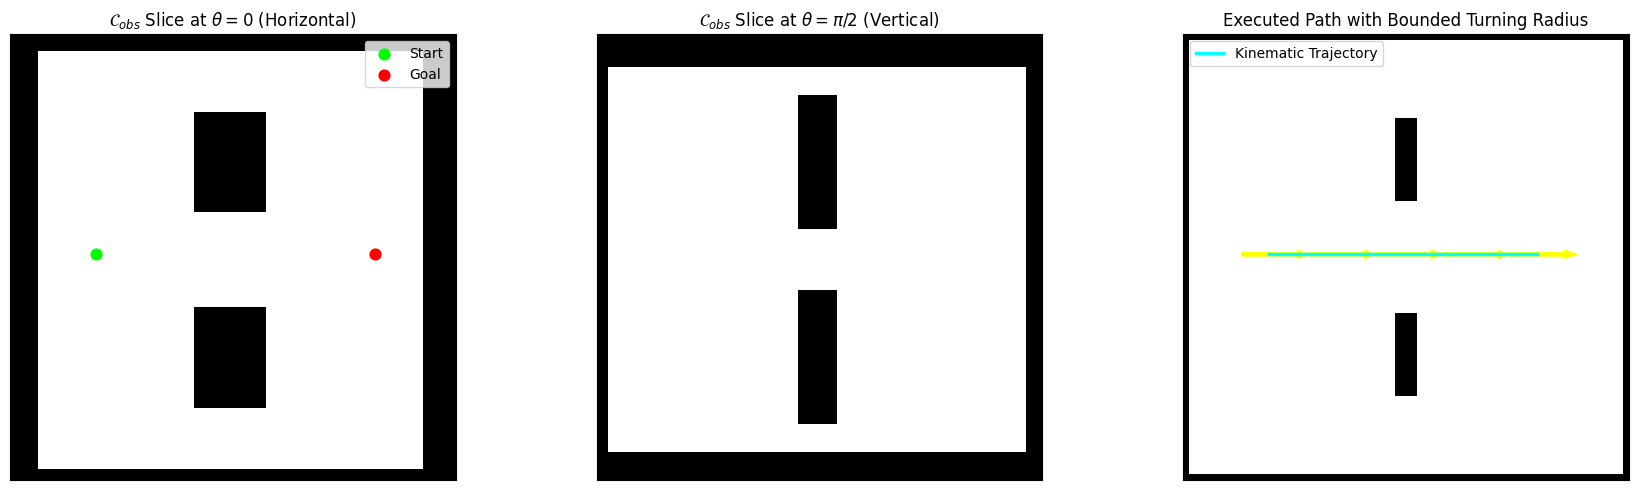

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, rotate
from collections import deque
import math

class SE2KinematicSpace:
    """
    Manages 3D Configuration Space (X, Y, Theta) using morphological operators
    and computes non-holonomic kinematic reachability.
    """
    def __init__(self, workspace: np.ndarray, body_length: int, body_width: int,
                 num_orientations: int = 16, min_turn_radius: float = 3.0):
        self.workspace = workspace.astype(bool)
        self.H, self.W = workspace.shape
        self.num_theta = num_orientations
        self.thetas = np.linspace(0, 2 * np.pi, num_orientations, endpoint=False)
        self.r_min = min_turn_radius

        # Base structuring element at theta = 0 (aligned with X-axis)
        self.body_length = body_length
        self.body_width = body_width
        self.base_footprint = self._create_rectangular_footprint(body_length, body_width)

        # 3D C-Space Tensor (X, Y, Theta)
        self.c_obs_3d = np.zeros((self.H, self.W, self.num_theta), dtype=bool)
        self._build_se2_cspace()

    def _create_rectangular_footprint(self, length: int, width: int) -> np.ndarray:
        """Constructs an asymmetric agent footprint centered at origin."""
        fp = np.zeros((length + 2, length + 2), dtype=bool)
        r_start = (fp.shape[0] - width) // 2
        c_start = (fp.shape[1] - length) // 2
        fp[r_start:r_start + width, c_start:c_start + length] = True
        return fp

    def _build_se2_cspace(self):
        """Generates 3D C-Space via slice-wise rotated Minkowski sums."""
        for idx, theta in enumerate(self.thetas):
            # Rotate body footprint by theta (in degrees for scipy)
            angle_deg = math.degrees(theta)
            rotated_fp = rotate(self.base_footprint.astype(float), angle_deg,
                                reshape=True, order=0) > 0.5

            # Reflected structuring element (-B) for Minkowski sum: O ⊕ (-B)
            reflected_fp = np.flip(np.flip(rotated_fp, axis=0), axis=1)

            # Morphological 2D Dilation
            dilated_slice = binary_dilation(self.workspace, structure=reflected_fp)
            self.c_obs_3d[:, :, idx] = dilated_slice

    def get_kinematic_primitives(self, step_size: float = 2.0):
        """
        Defines discrete non-holonomic motion primitives (Reeds-Shepp / Dubins):
        [Steer Neutral, Steer Left (R_min), Steer Right (R_min)]
        """
        d_theta = step_size / self.r_min
        return [
            ("S", step_size, 0.0),       # Straight
            ("L", step_size, d_theta),   # Left turn at maximum curvature
            ("R", step_size, -d_theta)   # Right turn at maximum curvature
        ]

    def plan_kinematic_path(self, start_pose: tuple, goal_pose: tuple):
        """
        Breadth-First Lattice Search over SE(2) satisfying bounded curvature.
        Pose format: (x, y, theta_idx)
        """
        primitives = self.get_kinematic_primitives(step_size=2.0)

        # Discretized search queues
        queue = deque([(start_pose[0], start_pose[1], start_pose[2], [])])
        visited = set()
        visited.add(start_pose)

        goal_x, goal_y, goal_th = goal_pose

        while queue:
            cx, cy, c_th_idx, path = queue.popleft()
            current_theta = self.thetas[c_th_idx]
            current_state = (cx, cy, c_th_idx)

            # Goal check with spatial and angular tolerance
            if math.hypot(cx - goal_x, cy - goal_y) < 2.5 and abs(c_th_idx - goal_th) <= 1:
                return path + [current_state]

            for _, step, d_th in primitives:
                # Integrate kinematics
                next_theta = (current_theta + d_th) % (2 * np.pi)
                next_x = cx + step * math.cos(next_theta)
                next_y = cy + step * math.sin(next_theta)

                # Discretize continuous state back to grid coordinates
                nx_grid, ny_grid = int(round(next_x)), int(round(next_y))
                nth_idx = int(round(next_theta / (2 * np.pi / self.num_theta))) % self.num_theta

                if 0 <= nx_grid < self.W and 0 <= ny_grid < self.H:
                    # Check collision inside SE(2) morphological volume
                    if not self.c_obs_3d[ny_grid, nx_grid, nth_idx]:
                        state_key = (nx_grid, ny_grid, nth_idx)
                        if state_key not in visited:
                            visited.add(state_key)
                            queue.append((next_x, next_y, nth_idx, path + [current_state]))
        return []


def run_se2_demo():
    # 1. Workspace setup with an asymmetric bottleneck
    W, H = 80, 80
    workspace = np.zeros((H, W), dtype=bool)

    # Outer boundaries
    workspace[0, :] = workspace[-1, :] = workspace[:, 0] = workspace[:, -1] = True

    # Corridor with an angled chicane
    workspace[15:65, 38:42] = True
    workspace[30:50, 38:42] = False  # Aperture window

    # 2. Instantiate SE(2) Space (Rectangular footprint: 10 units long, 4 units wide)
    se2 = SE2KinematicSpace(
        workspace,
        body_length=10,
        body_width=4,
        num_orientations=16,
        min_turn_radius=4.5
    )

    # 3. Define Start and Goal (X, Y, Theta_Index)
    start_pose = (15, 40, 0)                  # Pointing East (θ = 0)
    goal_pose = (65, 40, 0)                   # Pointing East (θ = 0)

    path = se2.plan_kinematic_path(start_pose, goal_pose)

    # 4. Visualization: Slices of the 3D C-Space
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Slice 1: θ = 0 rad (Horizontal footprint)
    axes[0].imshow(se2.c_obs_3d[:, :, 0], cmap="binary", origin="lower")
    axes[0].set_title(r"$\mathcal{C}_{obs}$ Slice at $\theta = 0$ (Horizontal)")
    axes[0].scatter([start_pose[0]], [start_pose[1]], color="lime", label="Start", s=60)
    axes[0].scatter([goal_pose[0]], [goal_pose[1]], color="red", label="Goal", s=60)
    axes[0].legend()

    # Slice 2: θ = π/2 rad (Vertical footprint - completely seals the horizontal corridor)
    vert_idx = se2.num_theta // 4
    axes[1].imshow(se2.c_obs_3d[:, :, vert_idx], cmap="binary", origin="lower")
    axes[1].set_title(r"$\mathcal{C}_{obs}$ Slice at $\theta = \pi/2$ (Vertical)")

    # Slice 3: Executed Kinematic Trajectory Projected on Workspace
    axes[2].imshow(workspace, cmap="binary", origin="lower")
    if path:
        px = [p[0] for p in path]
        py = [p[1] for p in path]
        axes[2].plot(px, py, color="cyan", linewidth=2.5, label="Kinematic Trajectory")

        # Plot robot footprint orientation at sampling intervals
        for step in path[::6]:
            x, y, th_idx = step
            theta = se2.thetas[th_idx]
            dx = (se2.body_length / 2) * math.cos(theta)
            dy = (se2.body_length / 2) * math.sin(theta)
            axes[2].arrow(x - dx, y - dy, 2 * dx, 2 * dy, color="yellow", width=0.6, head_width=1.5)

    axes[2].set_title("Executed Path with Bounded Turning Radius")
    axes[2].legend(loc="upper left")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_se2_demo()

---

### 5. Architectural Comparison: 2D vs. $SE(2)$ vs. Non-Holonomic Control

| Dimension | Standard Morphological $\mathbb{R}^2$ | Metric $SE(2)$ Sliced Morphology | Non-Holonomic Sub-Riemannian $SE(2)$ |
| --- | --- | --- | --- |
| **State Manifold** | $\mathbf{x} \in \mathbb{R}^2$ | $(\mathbf{x}, \theta) \in \mathbb{R}^2 \times S^1$ | $(\mathbf{x}, \theta) \in SE(2)$ under contact distribution $\Delta$ |
| **Structuring Element** | Static symmetric disk $\mathcal{B}$ | Rotation-parametrized family $\mathbf{R}(\theta)\mathcal{B}_0$ | Sub-Riemannian / Dubins reachable set $\mathcal{K}_{\Delta s}$ |
| **Operator Invariance** | Vector translations $(\mathbb{R}^2, +)$ | Rigid motions $SE(2)$ (Left-invariant) | Group actions constrained to horizontal bundle |
| **Medial Axis Behavior** | Equidistant Euclidean ridges | Equidistant hyper-surfaces across slices | Curvature-constrained ridge paths ($\kappa \le 1/R_{min}$) |
| **Affordance Scope** | Omnidirectional clearance | Orientation-dependent passage | Dynamically executable clearance horizons |

Treating the configuration space as a foliation of 2D morphological dilations enables efficient GPU array parallelization for each orientation slice $\theta_i$, while the non-holonomic reachability kernel prunes dynamically infeasible edges before high-level deliberation occurs.